
## Interference of Sources

In the standard sources in MEEP, it is not possible to directly define the phase parameters of the emitted electromagnetic wave.

If we need to simulate the interference of several sources with different phase shifts, we can use the [CustomSource](https://meep.readthedocs.io/en/latest/Python_User_Interface/#customsource). This approach allows us to specify the source's parameters—such as **phase shift**, **time delay**, etc.—within the user-defined function that describes the source's time profile.


In [1]:
# inicializaci a  vystup skriptov v kapitole MEEP Sources

import meep as mp 
import matplotlib.pyplot as plt


dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

def src_plot(dx, dy, data, res=1):
    # pomocna funkcia pre zobrazenie zdrojov v MEEP 
    # plotting 2D wave from source and wave cross section at y=50
    fig = plt.figure(figsize=(11,5))
    ax = fig.add_subplot(121)
     
    plt.imshow(data, interpolation='spline36', cmap='bwr', alpha=1.0, 
               extent=(0, dx, 0, dy), norm=plt.Normalize(-0.1, 0.1))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid()

    ax = fig.add_subplot(122)
    plt.plot(data[50*res,:], label='Y = 50')
    plt.xlabel('X')
    plt.grid()
    plt.legend()
    plt.show()


-----------
Initializing structure...
time for choose_chunkdivision = 0.000144958 s
Working in 2D dimensions.


Computational cell is 100 x 100 x 0 with resolution 4
time for set_epsilon = 0.076776 s
-----------


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (400 timesteps)


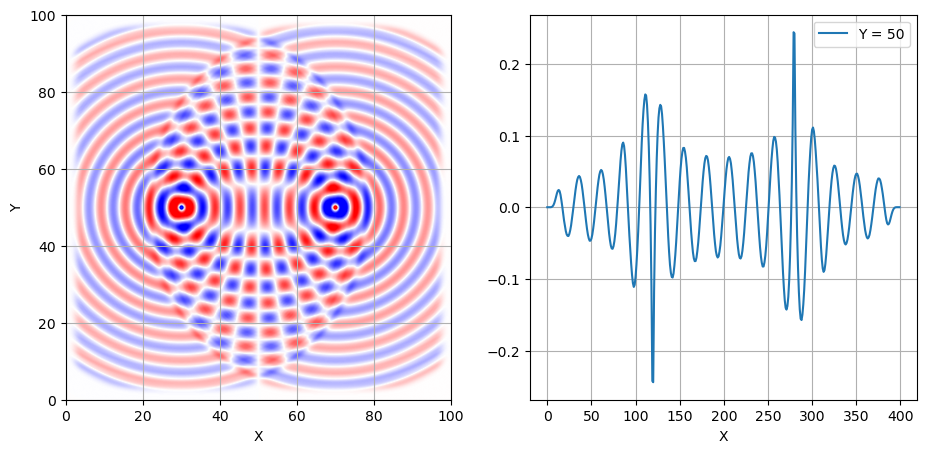

In [2]:
%matplotlib inline
import numpy as np
import meep as mp

def src_01(t):            # spojity zdroj
    return np.sin(t)  

def src_02(t):            # spojity zdroj s fazovym posunom PI
    return np.sin(t - np.pi)

sources = [mp.Source(mp.CustomSource(src_func=src_01), 
                component = mp.Ez,
                center = mp.Vector3(-20,0,0)),
           
           mp.Source(mp.CustomSource(src_func=src_02), 
                component = mp.Ez,
                center = mp.Vector3(20,0,0))
          ]
                     
sim = mp.Simulation(cell_size=area, boundary_layers=[mp.PML(5.0)],
                    geometry=[], sources=sources, resolution=4)

sim.run(until=50)
data = sim.get_array(center=mp.Vector3(), size=area, component=mp.Ez)
src_plot(dx, dy, data.transpose(), 4)

<!---  REMOVE -->  
### Animácia časového vývoja poľa

<!-- REMOVE -->
<img src="./img/img_interf_01.gif" >

<!-- REMOVE -->
<img src="./img/img_interf_02.gif" >